In [45]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import csv

import scipy.io.wavfile as wavfile
import scipy.signal as signal
import sounddevice

def getSamples(tList, fct, f, a = 1, phi = 0):
    return [fct(t, f, a, phi) for t in tList]

def pltStemWrapper(timeAxis, fct, f, a = 1, phi = 0):
    plt.stem(timeAxis, getSamples(timeAxis, fct, f, a, phi))
    
def pltPlotWrapper(timeAxis, fct, f, a = 1, phi = 0):
    plt.plot(timeAxis, getSamples(timeAxis, fct, f, a, phi))


In [46]:
def signalSin(t, f, a, phi):
    return a*np.sin(2*np.pi*f*t + phi)

def signalCos(t, f, a, phi):
    return a*np.cos(2*np.pi*f*t + phi)

def signalSawtooth(t, f, a, phi):
    return a*np.mod(2*f*np.pi*t + phi, 2*np.pi)

def signalSquare(t, f, a, phi):
    return np.sign(semnalSin(t, f, a, phi))

def signalIdentity(t):
    return t


In [47]:
class Axis:
    def __init__(self, time_of_view = 1, sampling_rate = 441e2):
        self.time_of_view = time_of_view                          # seconds
        
        self.sampling_rate = sampling_rate                        # Hertz
        self.sampling_period = 1./self.sampling_rate              # seconds
        self.n_samples = self.time_of_view/self.sampling_period   # no unit of measure 
        
        self.time = np.linspace (0, self.time_of_view, int(self.n_samples + 1), dtype = 'complex_')  # seconds
        

In [48]:
class Signal:
    def __init__(self, axis, frequency = 440, amplitude = 1e4, phase = 0, w = 1):
        self.axis = axis
        self.frequency = frequency                                # Hertz
        self.amplitude = amplitude                                # meters
        self.phase = phase                                        # radians
        
        self.w = w
        self.signal = [(math.e ** (-2.0 * np.pi * 1j * w * t)) * self.sin(self.amplitude, self.frequency, t, self.phase) for t in self.axis.time]
        
    def stem(self):
        plt.grid(True)
        plt.stem (self.axis.time, self.signal)
        
    def plot(self):
        plt.grid(True)
        plt.plot (self.axis.time, self.signal)
        
    def stemRealImag(self):
        plt.grid(True)
        reals = [x.real for x in self.signal]
        imags = [x.imag for x in self.signal]
        plt.stem (reals, imags)
    
    def plotRealImag(self):
        plt.grid(True)
        reals = [x.real for x in self.signal]
        imags = [x.imag for x in self.signal]
        plt.plot (reals, imags)
    
    @classmethod
    def sin(cls, amplitude, frequency, time, phase):
        return float(amplitude) * np.sin (2.0 * np.pi * frequency * time + float(phase))
    
    # sum pe toate esantioanele din semnal   ori expoinentiala de data trecuta/N(nr esantioane)
        ####self.fourier = sum([(math.e ** (-2.0 * np.pi * 1j * w * t / self.axis.time_of_view)) * self.sin(self.amplitude, self.frequency, t, self.phase) for t in self.axis.time])
            


In [49]:
# ex 2
# a

# ts = 3600s
# fs = 1/ts = 1/3600s = 2.77*10^(-4) Hz
# n_samples = 18288

# b
# time_of_view = n_samples/fs = n_samples * ts = 18288*3600 s = 65836800 s = 18288 h = 762 d

# c
# esantionat corect si optim => fs = max(frecvente prezente in semnal) => 
# => fmax = fs => fmax = 2.77*10^(-4) Hz

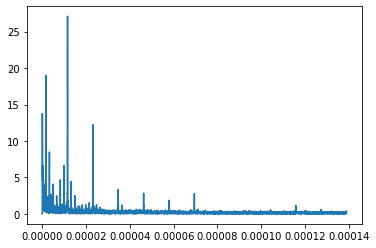

In [141]:
n_samples = 18288

x = None
with open('trafic.csv', newline='') as f:
    reader = csv.reader(f)
    x = list(reader)
    x = [int(elem[0]) for elem in x]
    x = np.asarray(x)
    
X = np.fft.fft(x)

X = abs(X/n_samples)
X = X[:int(n_samples/2)]

fs = 1/3600

f = np.linspace(0, int(n_samples/2), int(n_samples/2))
f = f * (fs/n_samples) 

X[:5] = 0      # (e: eliminam componenta continua)

plt.plot(f, X)


In [142]:
main_freqs_amplitudes = np.sort(X)[::-1]
main_freqs_amplitudes = main_freqs_amplitudes[:6]

main_freqs = []
for (sample, a) in enumerate(X):
    if a in main_freqs_amplitudes:
        main_freqs.append(f[sample])

for f in main_freqs:
    t = 1/f
    t_in_hours = t/3600
    t_in_days = t_in_hours/24
    t_in_weeks = t_in_days/7
    t_in_months = t_in_days/30
    t_in_years = t_in_days/365

    print("-------------------------")
    print(f"\nf: {f}\n")
    print(f"t: {round(t)}")
    print(f"t_in_hours: {round(t_in_hours)}")
    print(f"t_in_days: {round(t_in_days)}")
    print(f"t_in_weeks: {round(t_in_weeks)}")
    print(f"t_in_months: {round(t_in_months)}")
    print(f"t_in_years: {round(t_in_years)}\n")



-------------------------

f: 7.595367433494964e-08

t: 13165920
t_in_hours: 3657
t_in_days: 152
t_in_weeks: 22
t_in_months: 5
t_in_years: 0

-------------------------

f: 1.0633514406892949e-07

t: 9404229
t_in_hours: 2612
t_in_days: 109
t_in_weeks: 16
t_in_months: 4
t_in_years: 0

-------------------------

f: 1.6557901005019021e-06

t: 603941
t_in_hours: 168
t_in_days: 7
t_in_weeks: 1
t_in_months: 0
t_in_years: 0

-------------------------

f: 1.1575339968646325e-05

t: 86391
t_in_hours: 24
t_in_days: 1
t_in_weeks: 0
t_in_months: 0
t_in_years: 0

-------------------------

f: 1.1590530703513315e-05

t: 86277
t_in_hours: 24
t_in_days: 1
t_in_weeks: 0
t_in_months: 0
t_in_years: 0

-------------------------

f: 2.315067993729265e-05

t: 43195
t_in_hours: 12
t_in_days: 0
t_in_weeks: 0
t_in_months: 0
t_in_years: 0



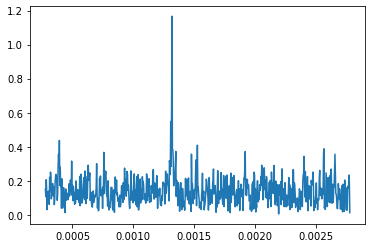

In [143]:
# g
starting_sample = 24*30*10
hours_in_a_month = 24*30
n_samples_g = hours_in_a_month

X_g = X[starting_sample : starting_sample + hours_in_a_month]

f_g = np.linspace(starting_sample, hours_in_a_month, n_samples_g)
f_g = f_g * (fs/n_samples_g)

plt.plot(f_g, X_g)


In [ ]:
# h 

